### Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
from scipy.stats import linregress
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

base_dir = os.getcwd()
parent_dir = os.path.dirname(base_dir)
os.chdir(parent_dir)

np.random.seed(101)

print(f"Current Directory: {os.getcwd()}")

Current Directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study


### Load in expert rating

In [7]:
# read in the doubling time data
dt = pd.read_csv("data/procdata/1_doublingRate/model_doubling_times.csv", usecols=["modelID", "global_doubling_time"], index_col="modelID")

# read in the RNA-seq data
df = pd.read_csv("data/rawdata/uhn_breast/omics/rna_tpm_hugo.tsv", sep="\t", index_col=0)

# filter to only protein-coding genes
gene_info = pd.read_csv("data/rawdata/uhn_breast/omics/geneInfo.tab", sep="\t", header=None, names=["ensembl_id", "symbol", "biotype"])
gene_info = gene_info[gene_info["biotype"] == "protein_coding"]
protein_coding_genes = set(gene_info["symbol"])

df = df.transpose()
df = df.loc[:, df.columns.isin(protein_coding_genes)]
print(f"Models in RNA-seq: {len(df)}") # if you kept a copy
df = np.log2(df + 1)
df = df.loc[:, df.var() > 0]

df = df.merge(dt, left_index=True, right_index=True, how="inner")

print(f"Models in DT list: {len(dt)}")
print(f"Models in Final DF: {df.shape[0]}")


print(df.shape)


Models in RNA-seq: 95
Models in DT list: 93
Models in Final DF: 74
(74, 19693)


In [3]:
df

,MT-CO1,MT-CO3,MT-CO2,MT-ATP6,MT-ND4,MT-ND3,EEF1A1,TMSB10,MT-CYB,MT-ND2,...,MYH8,USP17L17,DEFB129,TP53TG3E,USP17L13,RBMXL3,SMIM21,EEF1AKMT4-ECE2,SMIM23,global_doubling_time
REF020,12.358701,10.752498,10.828486,11.084496,11.892292,10.099874,10.955127,10.239539,10.740641,11.573335,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.519451
REF030,14.925404,14.253854,13.767674,13.119810,13.555997,12.427533,11.461439,10.805518,12.694438,12.817487,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.298313
S67990,14.277444,14.462233,13.026907,11.892657,12.092225,10.512523,11.791106,12.829713,11.576876,9.915790,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.093779
REF025,15.216328,14.252289,14.898194,13.810838,13.936683,13.723344,12.452326,11.445108,13.017748,12.734578,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.505512
S104987,14.247208,14.030540,12.716251,11.355566,11.847046,11.267366,12.588869,12.398303,10.869478,10.287839,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.368974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
REF023,12.172306,11.921328,10.782646,9.709118,8.998760,11.042384,11.479027,10.508785,9.390491,8.620550,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.373580
REF019,15.214189,14.663263,13.969780,13.364987,13.249087,13.921554,12.442612,10.438740,13.070116,12.393053,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.932056
S108099,12.824609,13.220747,12.120189,11.230723,11.270266,10.531654,12.474210,11.281420,10.630431,9.608606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.705676
REF048,14.866236,14.347057,13.154443,12.142471,12.215615,11.813372,11.863284,11.516897,11.524747,11.284402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.713066


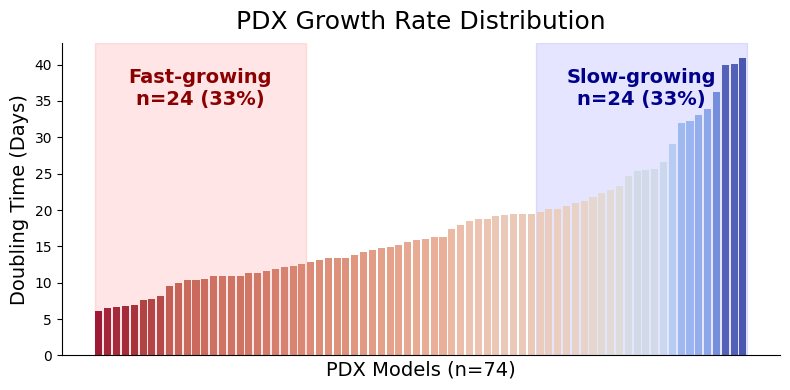

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

per_model_df = df.copy()

per_model_df = per_model_df.sort_values("global_doubling_time").reset_index(drop=True)

norm = mcolors.Normalize(vmin=per_model_df["global_doubling_time"].min(), 
                         vmax=per_model_df["global_doubling_time"].max())
cmap = plt.get_cmap("coolwarm_r")
custom_colors = [cmap(norm(v)) for v in per_model_df["global_doubling_time"]]

fig, ax = plt.subplots(figsize=(8, 4))

# Plot bars
sns.barplot(x=per_model_df.index, y="global_doubling_time", data=per_model_df, palette=custom_colors, ax=ax)

# 1. REMOVE X-AXIS TICK LABELS (Model Names)
ax.set_xticklabels([]) 
ax.set_xticks([]) # Removes the tick marks entirely for a cleaner baseline

# Calculate indices for shading (1/3 of 81 = 27)
n_models = len(per_model_df)
one_third = n_models // 3

# 1. Shade Fast-growing models (Left side / Red-ish zone)
ax.axvspan(-0.5, one_third - 0.5, color='red', alpha=0.1, zorder=0)
ax.text(one_third/2 - 0.5, ax.get_ylim()[1]*0.8, f"Fast-growing\nn={one_third} (33%)", 
        color='darkred', weight='bold', ha='center', fontsize=14)

# 2. Shade Slow-growing models (Right side / Blue-ish zone)
ax.axvspan(n_models - one_third - 0.5, n_models - 0.5, color='blue', alpha=0.1, zorder=0)
ax.text(n_models - one_third/2 - 0.5, ax.get_ylim()[1]*0.8, f"Slow-growing\nn={one_third} (33%)", 
        color='darkblue', weight='bold', ha='center', fontsize=14)

# Styling
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
# Short & Clean Labels
ax.set_title("PDX Growth Rate Distribution", fontsize=18, pad=10)
ax.set_ylabel("Doubling Time (Days)", fontsize=14)
ax.set_xlabel(f"PDX Models (n={n_models})", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("results/1_doublingRate/figure2c_global_DT.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
df.head()
df.to_csv("data/procdata/1_doublingRate/rna_doubling_time_merged.csv")

In [4]:
def select_variant_features(df, n_top=None, var_threshold=None):
    """
    Selects features based on their variance across samples.
    
    Parameters:
    - df: Input DataFrame (samples as rows, features as columns)
    - n_top: Integer. If provided, returns the top N features with highest variance.
    - var_threshold: Float. If provided, returns features with variance > threshold.
    
    Returns:
    - DataFrame subset with selected features.
    """
    # Calculate variance for each column (feature)
    variances = df.var(axis=0)
    
    if n_top is not None:
        # Get indices of the top N variances
        keep = variances.nlargest(n_top).index
        print(f"Selected top {n_top} most variant features.")
    
    elif var_threshold is not None:
        # Filter by threshold
        keep = variances[variances > var_threshold].index
        print(f"Selected {len(keep)} features with variance > {var_threshold}.")
        
    else:
        print("Please provide either n_top or var_threshold.")
        return df

    return df[keep]

### Set target and features

In [5]:
def corr_features(X, thres):
    # 1. Compute correlation matrix
    corr_matrix = X.corr().abs()

    # 2. Select upper triangle of correlation matrix
    # (This avoids comparing a gene to itself or comparing A-B and B-A)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # 3. Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > thres)]

    print(f'Original number of features: {X.shape[1]}')
    print(f'Num highly correlated features to drop: {len(to_drop)}')
    
    # 4. Drop features 
    X_filtered = X.drop(columns=to_drop)
    print(f'Number of features remaining: {X_filtered.shape[1]}')

    return X_filtered

In [6]:
y = df["global_doubling_time"]
X = df.drop(columns=["global_doubling_time"])
X_feature = select_variant_features(X, n_top=2200)
X_selected = corr_features(X_feature, thres=0.85)
X_final = select_variant_features(X_selected, n_top=2000)
# mergeback with y and save the final df for ML
final_df = X_final.merge(y, left_index=True, right_index=True)
final_df.to_csv("data/procdata/1_doublingRate/rna_HVG2000_doubling_time_merged.csv")

Selected top 2200 most variant features.


NameError: name 'corr_features' is not defined

In [5]:
y = df["global_doubling_time"]
X = df.drop(columns=["global_doubling_time"])
X_feature = select_variant_features(X, n_top=100)
final_df = X_feature.merge(y, left_index=True, right_index=True)
final_df.to_csv("data/procdata/1_doublingRate/rna_HVG100_doubling_time_merged.csv")

Selected top 100 most variant features.


In [ ]:
y = df["global_doubling_time"]
X = df.drop(columns=["global_doubling_time"])
X_feature = select_variant_features(X, n_top=150)
final_df = X_feature.merge(y, left_index=True, right_index=True)
final_df.to_csv("data/procdata/1_doublingRate/rna_HVG150_doubling_time_merged.csv")

In [8]:
y = df["global_doubling_time"]
X = df.drop(columns=["global_doubling_time"])
X_feature = select_variant_features(X, n_top=200)
final_df = X_feature.merge(y, left_index=True, right_index=True)
final_df.to_csv("data/procdata/1_doublingRate/rna_HVG200_doubling_time_merged.csv")

Selected top 200 most variant features.


In [34]:
# 1. Run the redundancy filter on the Training Set ONLY
# We use a high threshold (e.g., 0.85) to remove near-duplicates
X_train_final = corr_features_fast(X_train_selected, thres=0.85)

# 2. Get the list of genes that survived the filter
final_genes = X_train_final.columns

# 3. Filter the Test Set to match the new Training Set
X_test_final = X_test_selected[final_genes]

print(f"Final feature count for modeling: {len(final_genes)}")

Original number of features: 3094
Num highly correlated features to drop: 382
Number of features remaining: 2712
Final feature count for modeling: 2712


### Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_test_final_scaled = scaler.transform(X_test_final)

# (Optional) Convert back to DataFrame if you want to keep gene names
X_train_final_scaled = pd.DataFrame(X_train_final_scaled, 
                                    index=X_train_final.index, 
                                    columns=X_train_final.columns)
X_test_final_scaled = pd.DataFrame(X_test_final_scaled, 
                                   index=X_test_final.index, 
                                   columns=X_test_final.columns)

In [37]:
# Save your local variables to CSV
X_train_final_scaled.to_csv("data/procdata/1_doublingRate/X_train_processed.csv")
X_test_final_scaled.to_csv("data/procdata/1_doublingRate/X_test_processed.csv")
y_train.to_csv("data/procdata/1_doublingRate/y_train.csv")
y_test.to_csv("data/procdata/1_doublingRate/y_test.csv")